# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Riccardo Monforte*

## Setup



In [ ]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn modules
import sklearn

#Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,classification_report, ConfusionMatrixDisplay
from sklearn.metrics import  RocCurveDisplay, roc_auc_score, accuracy_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

#Statistical libraries
from scipy.stats import chi2_contingency

In the following cell we define some helper functions that will be useful throughout the analysis.

In [36]:
def build_diagnostic_table(df, sample_n=5):

    """
    Constructs a summary table with relevant statistics to understand
    to guide data preprocessing decisions for each variable in a dataframe

    Inputs:
    - df: pandas DataFrame
    - sample_n: int, number of sample values to display

    Returns:
    - pandas DataFrame with summary statistics for each column

    """
    #Create an empty list that will store one dictionary per column
    rows = []

    #Store total number of rows of the dataframe
    n_rows = len(df)

    #loop over each column name in the dataframe
    for col in df.columns:

        #Extract the current column
        s = df[col]

        #Convert the dtype of the Series to string so it is easier to display
        dtype = str(s.dtype)

        #Count how many values non-null values are present in the column
        n_non_null = s.notna().sum()
        #Count how many null values are presentin the column
        n_missing = s.isna().sum()
        #Compute percentage of missing values in the column
        pct_missing = 100 * n_missing / n_rows

        #Count number of unique non missing values in the column
        n_unique = s.nunique(dropna=True)
        #Compute percentage of unique values 
        pct_unique = 100 * n_unique / n_rows
        
        #Compute the mode/modes of the column, ignoring missing values
        mode_vals = s.mode(dropna=True)
        if len(mode_vals) > 0:
            #Take the first mode
            most_freq_value = mode_vals[0]
            #Count the number of times the mode occurs in the column
            most_freq_count = (s == most_freq_value).sum()
            #Compute percentage of times the mode occurs in the column
            most_freq_pct = 100 * most_freq_count / n_rows
        else:
            #If there is no mode then the most frequent value is NA
            most_freq_value = np.nan
            most_freq_pct = np.nan

        #Extract a list of non NA sample values from the column
        sample_values = list(s.dropna().unique()[:sample_n])

        #Create a rough classification of the type of variable based on dtype and number of unique values
        if pd.api.types.is_bool_dtype(s):
        #If the column is boolean, classify it as boolean
            var_type_guess = "boolean"
        #if the column is numeric...
        elif pd.api.types.is_numeric_dtype(s):
            if n_unique <= 2:
                #Classify as binary if it as <= unique values
                var_type_guess = "binary_numeric"
            elif n_unique <= 10:
                #Classify as discrete or multiclass categorical if n_unique <= 10
                var_type_guess = "discrete_numeric_or_code"
            else:
                #Classify as proper numeric otherwise
                var_type_guess = "numeric"
        else:
            #If nor boolean or numeric
            if n_unique <= 4:
                #Binary categorical if n_unique <= 2
                var_type_guess = "low_card_categorical"
            elif n_unique <= 12:
                #Categorical with low cardinality if unique values <= 10
                var_type_guess = "low_card_categorical_ordinal"
            elif n_unique <= 20:
                #Categorical with high cardinality otherwise
                var_type_guess = "high_card_categorical"
            else:
                var_type_guess = "numeric"

        #Appen all columns in row as a dictionary
        rows.append({
            "column": col,
            "dtype": dtype,
            "var_type_guess": var_type_guess,
            "n_non_null": n_non_null,
            "n_missing": n_missing,
            "pct_missing": round(pct_missing, 2),
            "n_unique": n_unique,
            "pct_unique": round(pct_unique, 2),
            "most_freq_value": most_freq_value,
            "most_freq_pct": round(most_freq_pct, 2) if pd.notna(most_freq_pct) else np.nan,
            "sample_values": sample_values
        })

    #Construct dataframe
    diag = pd.DataFrame(rows)
    
    #Sort values in the dataframe first by % of missing values, then by number of unique values
    diag = diag.sort_values(by=["pct_missing", "n_unique"],ascending=[False, False])

    return diag


def cramers_v(x, y):
    """
    Compute Cramer's V statistic to understand the strenght of association between two categorical variables x and y.

    Args:
    - x: pandas Series or array-like, categorical variable
    - y: pandas Series or array-like, categorical variable
    Returns:
    - Cramer's V statistic, a value between 0 and 1 where higher values indicate stronger association between the two variables.
    """
    #Build table in which:
    # rows = categories of x, columns = categories of y,
    # cells = observed counts for each category combination
    table = pd.crosstab(x, y)
    #Extract chi-square statistic
    chi2 = chi2_contingency(table)[0]
    #Compute total number of observations in the contingency table
    n = table.sum().sum()
    #r = number of rows, k = number of columns
    r, k = table.shape
    #Cramer's V
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


def get_coefs(m, plot = False, feature_names = None, figsize = (5,5), figtitle = None, intercept = True):
    """Returns model coefficients in a data frame for a fitted linear model.
    
    Args:
        m: sklearn LinearRegression model object or pipeline with LinearRegression as final step
        plot: boolean value, should coefficients be plotted with error bars
        feature_names: list of feature names to use in the plot 
        figsize: tuple defining figure size
        figtitle: string defining figure title
        intercept: boolean value, should intercept be included in the plot
    """
    
    # Extract intercept and coefficients into a single array
    if isinstance(m, sklearn.pipeline.Pipeline):
        intercept_arr = np.ravel(m[-1].intercept_)
        coef_arr = np.ravel(m[-1].coef_)
    else:
        intercept_arr = np.ravel(m.intercept_)
        coef_arr = np.ravel(m.coef_)
    
    w = np.concatenate((intercept_arr, coef_arr))
    
    # Extract name of features
    if feature_names is None:
        feature_names = m[:-1].get_feature_names_out() if isinstance(m, sklearn.pipeline.Pipeline) else m.feature_names_in_
    feature_names = np.concatenate((['intercept'], feature_names))
    
    # Create a data frame
    w_df = pd.DataFrame({'feature': feature_names, 'coef': w}).sort_values("coef", ascending=False)

    if plot:
        if not intercept:
            w_df = w_df[w_df['feature'] != 'intercept']
        plt.figure(figsize=figsize)
        plt.barh(w_df['feature'], w_df['coef'])
        plt.ylabel('Features')
        plt.xlabel('Coefficient Value')
        plt.axvline(x=0, color=".5")
        if figtitle is not None:
            plt.title(figtitle)
        plt.grid()
        plt.show()
    
    return w_df

def bootstrap_l1_stability(
    X,
    y,
    preprocessor,
    C_list=None,
    n_bootstrap=100,
    inner_cv_splits=5,
    scoring="accuracy",
    threshold=1e-8,
    max_iter=3000,
    random_state=0,
    n_jobs=-1
):
    """
    Evaluate stability of L1-logistic feature selection via bootstrap.

    Args:
        X: training predictors (preferably pandas DataFrame)
        y: training target (preferably pandas Series)
        preprocessor: transformer or preprocessing pipeline to include in the model pipeline
        C_list: list or array of C values for GridSearchCV
        n_bootstrap: number of bootstrap resamples
        inner_cv_splits: number of CV folds inside each bootstrap
        scoring: metric used to tune C
        threshold: coefficients with absolute value below this are treated as zero
        max_iter: maximum number of iterations for LogisticRegression
        random_state: seed for reproducibility
        n_jobs: number of CPU cores used in GridSearchCV

    Returns:
        stability_df: summary table with stability measures for each feature
        coef_df: table of coefficient values across bootstrap samples
        best_c_values: best C selected in each bootstrap run
    """

    # Random number generator used to draw bootstrap samples.
    rng = np.random.RandomState(random_state)

    # List to store the coefficient vector from each bootstrap fit.
    coef_series_list = []

    # List to store the best C chosen in each bootstrap iteration.
    best_c_values = []

    # Number of observations in the training data.
    n_samples = len(X)

    # Repeat the whole fitting procedure on many bootstrap samples.
    for b in range(n_bootstrap):
        # Draw a bootstrap sample: same sample size as the original data,
        # but sampled with replacement.
        boot_idx = rng.choice(np.arange(n_samples), size=n_samples, replace=True)

        # Subset X using the sampled indices
        # Use .iloc when X is a pandas object, otherwise use standard indexing.
        if hasattr(X, "iloc"):
            X_boot = X.iloc[boot_idx]
        else:
            X_boot = X[boot_idx]

        # Subset y in the same way
        if hasattr(y, "iloc"):
            y_boot = y.iloc[boot_idx]
        else:
            y_boot = y[boot_idx]

        # Build the modelling pipeline:
        # preprocessing first, then L1-penalized logistic regression.
        model = make_pipeline(
            preprocessor,
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=max_iter,
                random_state=random_state + b
            )
        )

        # Cross-validation used inside the bootstrap sample
        # to choose the best value of C.
        inner_cv = StratifiedKFold(
            n_splits=inner_cv_splits,
            shuffle=True,
            random_state=random_state + b
        )

        # Grid search over the candidate C values.
        gs = GridSearchCV(
            estimator=model,
            param_grid={"logisticregression__C": C_list},
            scoring=scoring,
            cv=inner_cv,
            refit=True,
            n_jobs=n_jobs
        )

        # Fit the grid search on the current bootstrap sample.
        gs.fit(X_boot, y_boot)

        # Extract the best fitted model and its chosen C.
        best_model = gs.best_estimator_
        best_c_values.append(gs.best_params_["logisticregression__C"])

        # Recover the preprocessing and classifier step names from the pipeline.
        preprocess_step_name = list(best_model.named_steps.keys())[0]
        clf_step_name = list(best_model.named_steps.keys())[1]

        # Get the names of the transformed features after preprocessing.
        feature_names = best_model.named_steps[preprocess_step_name].get_feature_names_out()

        # Extract the coefficient vector from logistic regression
        # and flatten it to 1D.
        coefs = np.ravel(best_model.named_steps[clf_step_name].coef_)

        # Store coefficients as a pandas Series indexed by feature name.
        # This is important because the number of dummy variables may vary
        # slightly across bootstrap samples.
        coef_s = pd.Series(coefs, index=feature_names, name=f"bootstrap_{b}")
        coef_series_list.append(coef_s)

    # Combine all bootstrap coefficient vectors into one DataFrame.
    # Missing features in a given bootstrap sample are filled with 0.
    coef_df = pd.concat(coef_series_list, axis=1).T.fillna(0)

    # Convert the coefficient table to a NumPy array for summary calculations.
    coef_mat = coef_df.to_numpy()

    # Save the final list of feature names.
    feature_names_final = coef_df.columns.to_numpy()

    # Mark a feature as selected if its coefficient is sufficiently far from zero.
    selected_mat = (np.abs(coef_mat) > threshold).astype(int)

    # Build a summary table describing how stable each feature is.
    stability_df = pd.DataFrame({
        "feature": feature_names_final,
        "selection_frequency": selected_mat.mean(axis=0),
        "mean_coef": coef_mat.mean(axis=0),
        "median_coef": np.median(coef_mat, axis=0),
        "mean_abs_coef": np.abs(coef_mat).mean(axis=0),
        "positive_sign_frequency": (coef_mat > threshold).mean(axis=0),
        "negative_sign_frequency": (coef_mat < -threshold).mean(axis=0),
        "nonzero_count": selected_mat.sum(axis=0)
    }).sort_values(
        by=["selection_frequency", "mean_abs_coef"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return stability_df, coef_df, best_c_values

In [37]:
# To make this notebook's output identical at every run
rng = np.random.seed(0)

# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()


,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


# Introduction

This report investigates whether a child aged 5 to 17 in Malawi is likely to experience any form of depression or not. 

The analysis has two main goals:

- build a model to predict whether a child reports any depressive symptoms;
- identify the factors that appear most relevant in explaining this outcome;

To carry out this task, we are going to use a subset of UNICEF’s Multiple Indicator Cluster Survey (MICS), which collects information on the child, parent, and wider household environment between 2019 and 2020.

To analyse the data, we will mainly use a frequentist statistical approach. 
In particular, as a general outline, we begin with exploratory data analysis to examine the structure of the data, understand how to handle missing observations, and look for possible relationships between the target variable ("FCF26") and the available predictors. After that, we will use logistic regression with l1 penalty to make a selection of the most important and stable predictors that might explain child depression. This will drive the definition of a simple linear parametric model to be used as an interpretable baseline. Finally, we compare this simpler model with a more flexible approach, with the aim of understanding whether allowing for non linear patterns improves predictive performance.

# Exploratory Data Analysis and Feature Engineering

The main steps of the exploratory analysis are the following:

1. Check whether the target variable is imbalanced, since this would have to be taken into account in the modelling stage.

2. Build a diagnostic table for all available features in order to summarise missing values, number of unique values, data types, and overall data structure.

3. Classify the variables by type, so that the appropriate preprocessing steps can later be defined for each group of features.

4. Carry out a separate exploratory analysis for numeric and categorical variables.  
    4.1 - For numeric variables, this will mainly involve the correlation matrix and the corresponding heatmap.  
    4.2 - For categorical variables, we will use Cramér’s V to assess the strength of association with the target variable.

5. We define the preprocessing steps for each group of variables identified in this section, and combine them into a single preprocessing pipeline.

In [63]:
#Save the original database
df_clean_original = df.copy()

#Define the database that will be cleaned and preprocessed
df_clean = df.copy()

#Expect shape of dataframe
#print(df_clean.shape)

#Expect unique values inside the target variable "FCF26"
print(df_clean["FCF26"].value_counts(dropna=False))

#Drop the rows of the database for which FCF26 = "NO RESPONSE"
df_clean = df_clean[df_clean["FCF26"] != "NO RESPONSE"].copy()

#Drop the rows of the database for which FCF26 is missing (NaN)
df_clean = df_clean[df_clean["FCF26"].notna()].copy()

#Encode the target variable "FCF26" as binary values (0 and 1)
df_clean["FCF26"] = np.where(df_clean["FCF26"] == "NEVER", 0, 1)

#Split the original dataset into features ("X") and target variable ("y")
X = df_clean.drop(columns=["FCF26"], axis=1)
y = df_clean["FCF26"]

print(y.value_counts())
print(f"total values: {y.value_counts().sum()}")
print(f"The data cleaning on y has lead to the removal of {df_clean_original['FCF26'].shape[0] 
                                                           - df_clean['FCF26'].shape[0]} observations.")
print(f"After the data preprocessing steps the target variable is balanced with approximately {y.mean():.2f} of positive class and {1-y.mean():.2f} of negative class.")

FCF26
NEVER                 5905
A FEW TIMES A YEAR    4376
MONTHLY               1284
WEEKLY                1073
DAILY                  398
NaN                    103
NO RESPONSE             23
Name: count, dtype: int64
FCF26
1    7131
0    5905
Name: count, dtype: int64
total values: 13036
The data cleaning on y has lead to the removal of 126 observations.
After the data preprocessing steps the target variable is balanced with approximately 0.55 of positive class and 0.45 of negative class.


The target variable FCF26, which records child depression, is originally coded into five response categories, together with some missing values and "NO RESPONSE" entries. Since the aim of the project is to predict whether the child shows any form of depression, we recoded the variable into a binary outcome: 0 if the response was "NEVER", and 1 otherwise. Observations with missing values (NaN) or "NO RESPONSE" were removed, as they could not be meaningfully assigned to either class.
Eventually, we notice no relevant imbalance between the positive and the negative class.

In [64]:
diag_table = build_diagnostic_table(X)
print(diag_table.head(10))

   column    dtype                var_type_guess  n_non_null  n_missing  \
10    CL3  float64                       numeric        4151       8885   
23   FCD5   object          low_card_categorical        8155       4881   
85    HW5   object          low_card_categorical        9620       3416   
50    MA2   object                       numeric       10107       2929   
51    MA3   object          low_card_categorical       10107       2929   
33   WB14   object  low_card_categorical_ordinal       10157       2879   
11   CL13   object                       numeric       11073       1963   
32   WB6B   object  low_card_categorical_ordinal       11190       1846   
31   WB6A   object  low_card_categorical_ordinal       11195       1841   
12  FCD2A   object          low_card_categorical       11241       1795   

    pct_missing  n_unique  pct_unique              most_freq_value  \
10        68.16        45        0.35                          0.0   
23        37.44         3        0

From the diagnostic table, ordered for percentage of missing values, it stems out the numeric variable CL3 with a 68% of missing values. This variable corresponds to hours of child labor. Since the missing values of this variable might still be informative, we decided to keep that variable into the database, and use an imputation strategy that keeps into account values that have been imputed. This strategy will be kept also for the other numeric variables, while for categorical variables missing values will be encoded as a proper category.

In [40]:
#Get type of features by using the above descriptive table.

low_card_categorical_cols = diag_table.loc[diag_table["var_type_guess"] == "low_card_categorical", "column"].tolist()

low_card_categorical_ordinal_cols = diag_table.loc[diag_table["var_type_guess"] == "low_card_categorical_ordinal", "column"].tolist()

high_card_categorical_cols = diag_table.loc[diag_table["var_type_guess"] == "high_card_categorical", "column"].tolist()

numeric = diag_table.loc[diag_table["var_type_guess"] == "numeric", "column"].tolist()

boolean = diag_table.loc[diag_table["var_type_guess"] == "boolean", "column"].tolist()

binary = diag_table.loc[diag_table["var_type_guess"] == "binary_numeric", "column"].tolist()

discrete = diag_table.loc[diag_table["var_type_guess"] == "discrete_numeric_or_code", "column"].tolist()

print("low_card_categorical_cols:", low_card_categorical_cols)
print("low_card_categorical_ordinal_cols:", low_card_categorical_ordinal_cols)
print("high_card_categorical_cols:", high_card_categorical_cols)
print("numeric:", numeric)
print("boolean:", boolean)
print("discrete:", discrete)

#Convert boolean to object type so that those variables can be imputed and encoded as categorical variables in the future steps
df_clean[boolean] = df_clean[boolean].astype(object)

low_card_categorical_cols: ['FCD5', 'HW5', 'MA3', 'FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K', 'WS3', 'WS14', 'WS15', 'CB7', 'AF12', 'AF10', 'AF11', 'disability', 'DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E', 'VT1', 'VT9', 'VT22A', 'VT22B', 'VT22C', 'VT22D', 'VT22F', 'LS3', 'LS4', 'WB5', 'VT22E', 'VT22X', 'TA1', 'TA14', 'MSTATUS', 'HC8', 'HC14', 'WS7', 'CB4', 'CB11', 'HH7', 'HC11', 'HC12', 'HC13', 'HC15', 'HC17', 'HC19', 'TN1', 'HH6', 'HL4']
low_card_categorical_ordinal_cols: ['WB14', 'WB6B', 'WB6A', 'CB5B', 'CB5A', 'LS2', 'VT20', 'VT21', 'LS1', 'HC5', 'HC4', 'ethnicity']
high_card_categorical_cols: ['WS1', 'WS11']
numeric: ['CL3', 'MA2', 'CL13', 'WS4', 'WB4', 'wscore', 'HH1', 'HH2', 'CB3', 'CSURV']
boolean: ['CL2', 'CL12']
discrete: ['LN', 'FS4', 'CDEAD']


Based on the variable-type guesses produced by the diagnostic table function, we extract the names of the features belonging to each group. These groups are used right after to carry out separate exploratory analyses for numeric and categorical variables, and later to define the appropriate preprocessing steps for each type of feature.

## EDA on numeric variables

The objective of this section is to compute and display the correlation matrix between the numeric variables (including our target) in order to understand if we can anticipate some evident (linear) correlation.



In [41]:
#Get numeric colum names
num_cols = numeric + discrete

#Force the conversion to numeric
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors="coerce")

#Re-assign X and y after the cleaning processes
X = df_clean.drop(columns=["FCF26"], axis=1)
y = df_clean["FCF26"]

#Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rng, stratify=y)

# Build numeric-only training dataframe for correlation analysis
train_num = X_train[num_cols].copy()
train_num["FCF26"] = y_train.values

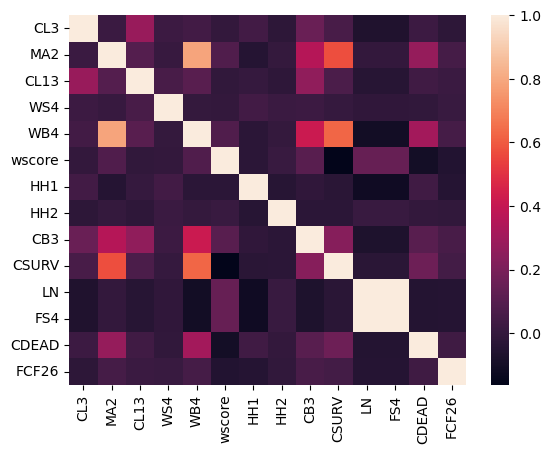

In [42]:
# Build the correlation matrix for numeric variables
corr_matrix = train_num.corr()

#plot heatmap
sns.heatmap(corr_matrix)
plt.show()

From the heatmap of the numerical features we can infer the following:

1) FCF26, our target variable, doesn't show strong linear relationship with any of the numerical predictors.
2) LN and FS4 are perfectly correlated. These variables represent Mother/Caretaker Name/Line number and can be therefore removed from the database. We will also remove HH1 and HH2 as they are IDs (cluster number and household number respectively)
3) There are no strong widespread linear dependencies among the other numberical features, suggesting limited redundancy among covariates, except for some cases (example CSURV, MA2 and WB4)
3) The variability of target variable y may be therefore be better explained by non linear relationships, interactions among predictors, or by the categorical variables.

In [43]:
columns_to_drop = ["LN", "FS4", "HH1", "HH2"]

#Remove these variables from the training and test sets
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

#Remove the variables from the list of discrete variables as well
discrete.remove("LN")
discrete.remove("FS4")
numeric.remove("HH1")
numeric.remove("HH2")


## EDA on categorical features

To study the relationship between categorical predictors and the target variable, we use Cramer’s V.  
A simple chi squared test of independence would tell us whether there is statistical evidence of an association between two categorical variables, but it does not provide an easily interpretable measure of the strenght of that association. 

Cramer’s V is directly based on the chi squared statistic. More precisely, it rescales the chi squared value by the sample size and by the dimensions of the contingency table, producing a number between 0 and 1. A value close to 0 indicates little or no association, while a value close to 1 indicates a stronger association between the two variables.

In our implementation, we first construct a contingency table between a categorical predictor and the binary target. We then compute the chi-squared statistic from that table and transform it into Cramer’s V. This provides a simple summary measure of how strongly each categorical variable is associated with the target.

As a rough guide, values below 0.1 usually indicate a very weak association, values between 0.1 and 0.3 a weak to moderate association, values between 0.3 and 0.5 a moderate association, and values above 0.5 a relatively strong association. These thresholds should not be treated as strict rules, but only as a practical way to compare variables within this dataset.

In [44]:
#EDA for categorical variables

#Getting categorical features' names
cat_cols = low_card_categorical_cols + low_card_categorical_ordinal_cols + high_card_categorical_cols + binary

#Creating a table to display Cramer's V
results = []

for col in cat_cols:
    x_temp = df_clean[col]
    y_temp = df_clean["FCF26"]

    results.append({
        "Features":col,
        "Cramer's V":cramers_v(x_temp,y_temp)
        }
    )

table = pd.DataFrame(results).sort_values("Cramer's V", ascending=False).reset_index(drop=True)

table.head(10)


,Features,Cramer's V
0,LS1,0.120772
1,LS2,0.112396
2,VT22A,0.098326
3,VT22B,0.097513
4,ethnicity,0.094885
5,FCD2H,0.094836
6,VT20,0.092055
7,AF10,0.090720
8,VT21,0.087947
9,LS3,0.087707


From the output of Cramer's V table, we see no categorical feature relevantly associated with the target variable.

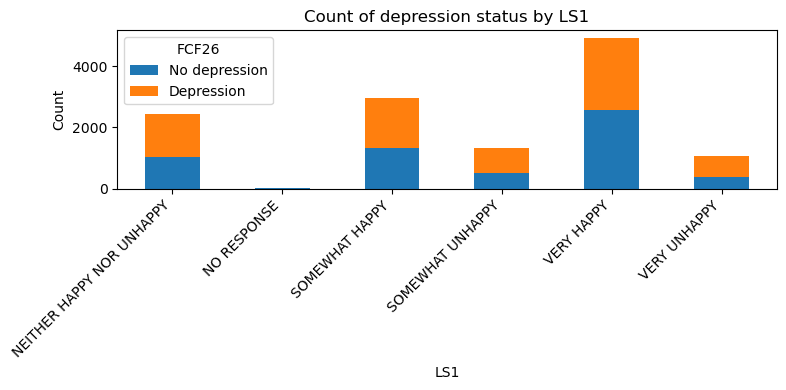

In [45]:
#Select how many top categories we want to inspect
n_topcat = 1

# Extract the names of the first n_topcat features from the association table
top_cat_cols = table.iloc[0:n_topcat, 0].to_list()

#Loop over each categorical feature name
for col in top_cat_cols:
    #Temporary dataframe in which we only have 
    # 1) the selected feature at each stage of the loop
    # 2) the target variable y
    temp_df = df_clean[[col, "FCF26"]].copy()

    #Create contingency table
    tab = pd.crosstab(temp_df[col], temp_df["FCF26"])

    #Create a stacked bar chart in which:
    #Each bar represents a level of the feature
    #The coloured segments within each bar represent the value of the target variable 
    tab.plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"Count of depression status by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="FCF26", labels=["No depression", "Depression"])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The figure above shows, as an example, the distribution of the target variable across the levels of the categorical feature with the highest Cramer’s V value.
In particular, LS1 represents general life satisfaction of the child's mother.
The shares of Depression and No Depression remain fairly similar across the different categories, which helps explain why the estimated association is still relatively weak.

## Pre-processing step definition

In [46]:
#Define the preprocessing steps within our pipeline for each type of varibale
low_cat_pre = Pipeline([
    ("low_cat_impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("low_cat_encode", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

low_cat_ord_pre = Pipeline([
    ("low_cat_ord_impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("low_cat_ord_encode", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])

bool_pre = Pipeline([ 
    ("bool_impute", SimpleImputer(strategy="constant", fill_value="Missing")), 
    ("bool_encode", OneHotEncoder(handle_unknown="ignore")) ])

num_pre = Pipeline([
    ("num_impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("num_scale", StandardScaler())    
])

disc_num_pre = Pipeline([
    ("disc_num_impute", SimpleImputer(strategy="median"))
])

high_cat_pre = Pipeline([
    ("high_cat_impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("high_cat_encode", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [47]:
#Define the preprocessor that will be used in the modelling pipeline
preprocessor = make_column_transformer(
    (low_cat_pre, low_card_categorical_cols + binary),
    (low_cat_ord_pre, low_card_categorical_ordinal_cols),
    (bool_pre, boolean),
    (num_pre, numeric),
    (disc_num_pre, discrete),
    (high_cat_pre, high_card_categorical_cols),
    verbose_feature_names_out=False
)

The preprocessing choices were defined separately for each group of variables identified in the EDA, with the aim of keeping the pipeline both interpretable and suitable for the models considered later.

1) for low-cardinality categorical variables, we use one-hot encoding. This is the most natural choice in this setting, since the number of levels is limited and the resulting expansion of the feature space remains manageable. It also preserves interpretability, as each level can still be read directly in the final design matrix.

2) For ordinal categorical variables, we use an ordinal encoder. In this case the ordering of the categories carries information, so it is preferable to preserve that structure rather than treat the levels as unrelated categories.

3) For high-cardinality categorical variables, we still use one-hot encoding rather than more aggressive encoding methods (like target encoding). Although these variables have more levels than the other categorical groups, in practice their cardinality remains moderate (at most 16 categories), so one-hot encoding does not inflate the feature space excessively. At the same time, it keeps the transformed variables easy to interpret, which is important given the emphasis of the project on understanding the role of the predictors.

4) For numeric variables, missing values are imputed using the median. This is a simple and robust choice, especially in the presence of skewed distributions or possible extreme values, where the mean could be more sensitive to outliers. We also set "add_indicator=True", so that the model receives an additional binary variable marking whether the original value was missing. This allows the model to separate the effect of the imputed numeric value from the effect of missingness itself. The numeric variables are then standardised. This is particularly important because part of the modelling strategy relies on penalised logistic regression. Since regularisation acts directly on the size of the coefficients, standardising the variables ensures that predictors measured on different scales are penalised more comparably.

5) For discrete numeric or coded variables, we apply median imputation but do not standardise them, as in these cases the scale often has a more direct categorical or counting interpretation.

6) Finally, for categorical variables with missing values, we handle missingness by creating an explicit "Missing" category through constant imputation. This is a relatively conservative choice, as it avoids dropping observations and does not force missing cases into one of the observed categories. In this way, the model can also learn whether missingness itself carries useful information.

# Model Fitting and Tuning

In this section we proceed as follows:

1. We use an L1-penalised logistic regression as a feature-selection tool.  
   The idea is to fit the model repeatedly on many bootstrap resamples of the training set, so that variable selection does not depend too heavily on a single realisation of the data. Within each bootstrap sample, the regularisation parameter "C" is tuned by cross-validation. Since the L1 penalty shrinks less informative coefficients exactly to zero, each fitted model produces a subset of selected features. By collecting the coefficients across all bootstrap runs, we can measure how often each feature is selected, the average size of its coefficient, and whether its sign is stable across resamples. This gives a more robust picture of which variables are consistently informative, rather than relying on a single fitted model.

2. We use the most stable features from this procedure to define a simpler and more interpretable baseline model, namely a logistic regression with L2 penalty.

3. Finally, we compare the performance of this model with that of a Random Forest classifier, which is able to capture non-linear patterns in the data. This allows us to assess whether a more flexible model leads to a substantial improvement in predictive performance, and helps guide the final model choice.

In [48]:
#Run the bootstrap stability function which has L1 logistic regression embedded.

#We define a range of C values to be tested in the inner loop of the bootstrap function.
C_list = np.logspace(-4, 1, num=12)

stability_df, coef_df, best_c_values = bootstrap_l1_stability(
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    C_list=C_list,
    n_bootstrap=20,
    inner_cv_splits=3,
    scoring="accuracy",  
    threshold=1e-8,
    max_iter=1000,
    random_state=0,
    n_jobs=-1
)

The bootstrap_l1_stability function is used to assess the stability of feature selection under an L1-penalised logistic regression. In an L1 logistic regression, the penalty shrinks the coefficients towards zero and can set some of them exactly equal to zero. This is why it is useful for feature selection: variables with coefficients shrunk to zero are effectively excluded from the model, while variables with non-zero coefficients are retained.

The procedure is repeated over a large number of bootstrap samples drawn from the training set. For each bootstrap sample, the model is fitted within a pipeline that includes both preprocessing and logistic regression with L1 penalty. The regularisation parameter C is tuned by GridSearch within each bootstrap sample, since the amount of regularisation directly affects how many variables are selected. 
In particular, The parameter C controls how strong the penalty is. Smaller values of C correspond to stronger regularisation, while larger values correspond to weaker regularisation.
Once the best model is obtained for a given bootstrap sample, the non-zero coefficients are recorded.

After repeating this process across all bootstrap samples, the results are summarised in order to identify the most stable predictors. In particular, for each feature we compute how often it is selected, the average and median value of its coefficient, and how often its sign is positive or negative across the different fitted models. This makes it possible to distinguish variables that are selected consistently from those that appear only occasionally.

The range of C values used in the GridSearch was chosen after some preliminary runs over a wider interval. Since those initial runs suggested that the optimal values of C tended to fall within a relatively narrow region, the final grid was restricted to values around that range. This was done mainly to reduce computation time while still keeping the tuning step sufficiently informative.

In [49]:
#Fit the preprocessor on the training set
preprocessor.fit(X_train, y_train)

#Transform the training set using the fitted preprocessor
X_train_transformed = preprocessor.transform(X_train)

# Transform the test set using the same fitted preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

#Convert transformed matrices to DataFrames
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [18, 54] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Here, the preprocessor is fitted on the training set and then applied to both the training and test feature matrices. This gives the transformed design matrices obtained after imputing missing values and encoding the categorical variables

In [59]:
#Stable features are those that get selected in more than 70% of the l1 logistic regression over the bootstrap samples
stable_features = stability_df[stability_df["selection_frequency"] >= 0.9]

print(stable_features.sort_values("mean_abs_coef", 
                                  ascending=False)[["feature", "selection_frequency", "mean_abs_coef", "median_coef"]].head(10))

# Among stable features, keep those with sufficiently large median coefficient magnitude
most_relevant_features = stable_features[abs(stable_features["median_coef"]) >= 0.05]["feature"].tolist()

# Build the final design matrices using only the selected feature names
X_train_final = X_train_transformed_df[most_relevant_features].copy()
X_test_final = X_test_transformed_df[most_relevant_features].copy()

print("Final training shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

print("Most relevant features:", most_relevant_features)
print(f"Selection process based on l1 penalty and bootstrap stability has reduced the number of features from {X_train_transformed.shape[1]}-post encoding to {len(most_relevant_features)}")


                                              feature  selection_frequency  \
49                                 AF12_NO DIFFICULTY                 0.90   
34                             WS7_YES, AT LEAST ONCE                 0.95   
0                                           VT22A_YES                 1.00   
1   WS11_PIT LATRINE: PIT LATRINE WITHOUT SLAB / O...                 1.00   
2                                             VT1_YES                 1.00   
3                                           VT22B_YES                 1.00   
50      WS11_FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK                 0.90   
51                                            VT9_YES                 0.90   
35                  MSTATUS_Formerly married/in union                 0.95   
52                                            DV1D_NO                 0.90   

    mean_abs_coef  median_coef  
49       0.864299     0.825123  
34       0.811698     0.684939  
0        0.585745     0.353865  
1        

We select the most stable features as those that are chosen in at least 90% of the bootstrap L1 logistic regression runs. We then apply a second filter, requiring the absolute median value of the coefficient to be at least 0.05. The median is used instead of the mean because it is more robust to extreme values. Since, for computational reasons, the bootstrap procedure was run on a limited number of resamples, this provides a more stable summary of the coefficient size. The features that satisfy both criteria are retained for the final baseline model.

## Baseline Model - Logistic Regression with L2 penalty

In [51]:
# Fit a logistic regression penalty l2 on the selected features
log_model2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=3000,
    random_state=rng
)

#Tune the model on a list of C values
gs2 = GridSearchCV(log_model2, 
                    param_grid={'C': C_list},
                    scoring = ["accuracy", "f1","recall","precision"],
                    cv = KFold(n_splits=5, shuffle = True, random_state=rng),
                    refit = "accuracy",
                    return_train_score = True) 

#Fit the tuned model
log2_tuned = gs2.fit(X_train_final, y_train)

#Get accuracy score on the test set
acc = log2_tuned.score(X_test_final, y_test)

print(f"Final logistic regression accuracy: {acc:.4f}")

#Get predicted probabilities for the positive class
y_proba = log2_tuned.predict_proba(X_test_final)[:, 1]

#Compute AUC score
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")

#Print best C value
best_c = gs2.best_params_['C']
print(f"Best C: {best_c:.4f}")

#Get the best fitted model from the grid search
ridge_best = gs2.best_estimator_

Final logistic regression accuracy: 0.6052
AUC: 0.6327
Best C: 1.2328


At this point, we fit our baseline model on the subset of variables selected through the bootstrap L1 procedure. The model is a logistic regression with l2 penalty, and the value of the regularisation parameter C is chosen by cross-validation over a grid of candidate values.

The role of the L2 penalty is different from that of the L1 penalty used in the selection step. L1 is useful because it can shrink some coefficients exactly to zero, so it naturally performs feature selection. L2, instead, does not usually remove variables completely, but it shrinks the coefficients towards zero. This tends to make the fitted model more stable and helps reduce overfitting, so it is mainly used here to improve generalisation on unseen data.

The parameter C works exactly in the same way as explained above for L1 and its best values is chosen by cross-validation on the training set, using accuracy as the criterion for model selection.

The final model is then evaluated on the test set using both accuracy and AUC. Accuracy represents the proportion of observations that are classified correctly.

AUC, instead, measures how well the model separates the two classes across all possible classification thresholds. While accuracy depends on a specific threshold, AUC gives a more general measure of how well the model ranks positive cases above negative ones.

In our case, both accuracy and AUC are around 0.60. This means that the model is doing better than random classification, but only to a limited extent. So there is some predictive signal in the selected variables, but the relationship with the target is not particularly strong. This is in line with the earlier exploratory analysis, where the associations with the outcome did not appear especially strong.

In [52]:
# Compute and print the classification report for the base model
print(classification_report(y_test, 
                            log2_tuned.predict(X_test_final), 
                            target_names = ['No Depression','Depression']))


               precision    recall  f1-score   support

No Depression       0.58      0.48      0.52      1772
   Depression       0.62      0.71      0.66      2139

     accuracy                           0.61      3911
    macro avg       0.60      0.59      0.59      3911
 weighted avg       0.60      0.61      0.60      3911



The classification report gives a more detailed view of the model’s behaviour across the two classes. The most notable result is the relatively high recall for the Depression class, which is equal to 0.71. This means that the model is able to identify around 71% of the children who are actually classified as depressed in the test set. 

The precision for the Depression class is instead 0.62. This means that, among all children predicted as depressed, around 62% are actually depressed. So the model is fairly good at capturing positive cases, but it also produces a non-negligible number of false positives.

For the No Depression class, performance is weaker. The recall is 0.48, which means that the model correctly identifies less than half of the children who are actually not depressed. This suggests that the model tends to miss a substantial part of the negative class, often assigning these observations to the positive group instead. The precision for No Depression is 0.58, meaning that when the model predicts the absence of depression, this prediction is correct in about 58% of cases.

The F1-score, which combines precision and recall into a single measure through their harmonic mean, confirms this pattern. It is higher for the Depression class (0.66) than for the No Depression class (0.52), showing that the model is clearly more effective at detecting depressed children than at correctly recognising non-depressed ones.

Overall, these results suggest that the model is more sensitive to the positive class than to the negative one. From an applied point of view, this may be seen as a reasonable trade-off if the main priority is to identify as many potentially depressed children as possible, even at the cost of a larger number of false positives.

Even though the predictive performance of the model is fairly limited, one important advantage of logistic regression is that it allows us to inspect the coefficients directly. This makes the model easier to interpret than more complex alternatives.

The coefficients are linked to the odds of the positive class, that is, the ratio between the probability of depression and the probability of no depression, given the set of features. In particular, a one unit increase in a predictor multiplies the odds by $e^{\beta_j}$, holding the other variables fixed. A positive coefficient therefore increases the odds of being classified as depressed, while a negative coefficient decreases them.

For this reason, even if the model is not especially strong from a predictive point of view, it can still give a useful indication of which variables are most important within the model. 

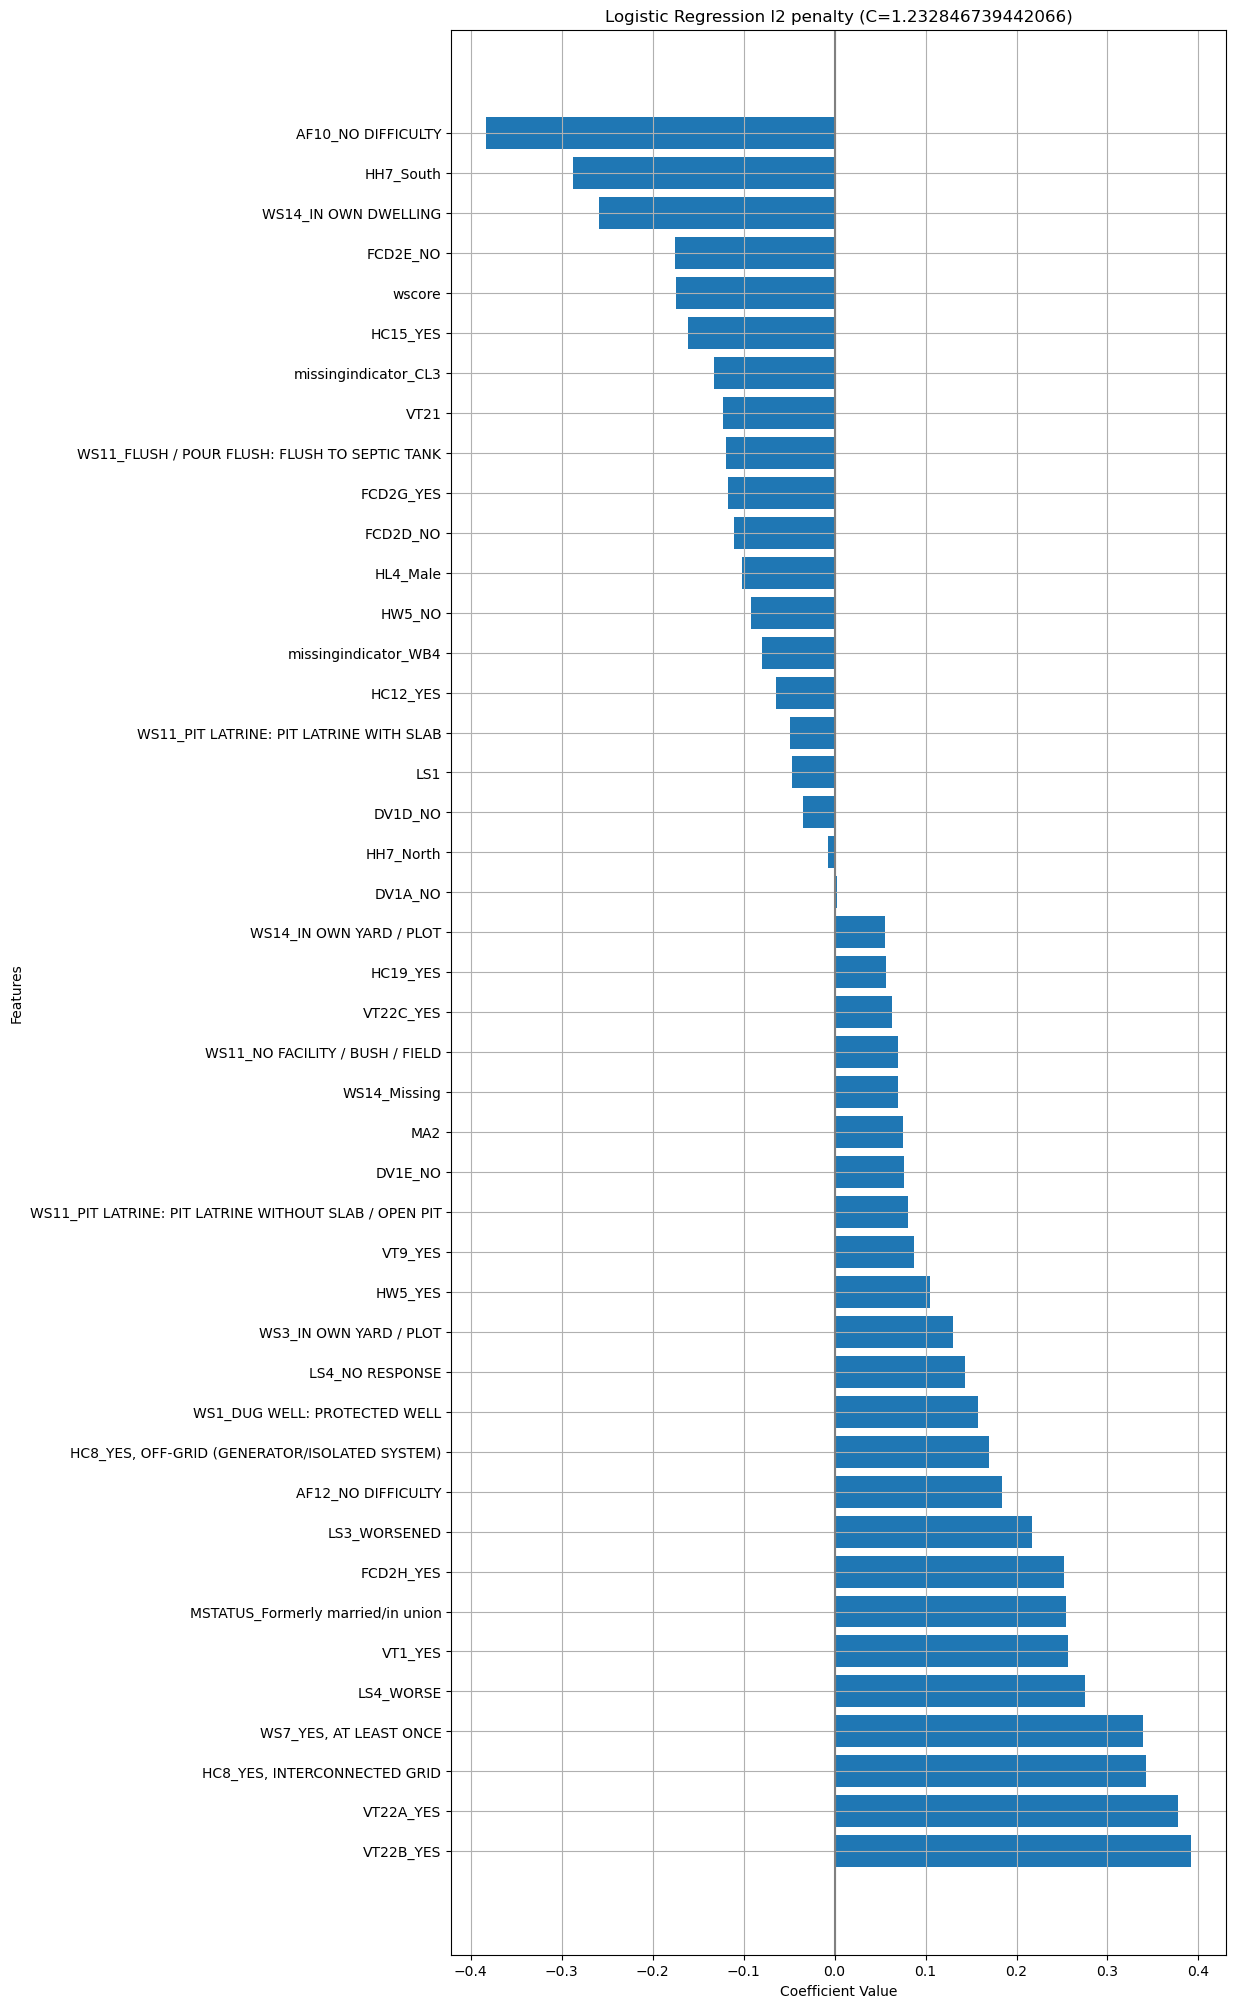

,feature,coef
4,VT22B_YES,0.391741
1,VT22A_YES,0.377388
8,"HC8_YES, INTERCONNECTED GRID",0.341949
23,"WS7_YES, AT LEAST ONCE",0.339330
5,LS4_WORSE,0.274822
3,VT1_YES,0.257029
24,MSTATUS_Formerly married/in union,0.254013
6,FCD2H_YES,0.252348
9,LS3_WORSENED,0.216700
31,AF12_NO DIFFICULTY,0.183637


In [53]:
# Plot the coefficients using the helper function
get_coefs(
    ridge_best,
    plot=True,
    figsize=(10,25),
    figtitle=f"Logistic Regression l2 penalty (C={best_c})",
    intercept=False
)

In the plot above we show the variables present in the final l2 model and along with their estimated coefficient. Variables like HH7 South, a categorical variable indicating the region in which the household is located or AF10_NO_Difficulty, which refers to the absence of difficulty in remembering or concentrating for the mother, stands out as being some of the most important for the prediction of the No Depression class.
By contrast, VT22A_YES and VT22B_YES, which refer respectively to the mother’s reported experience of ethnic/immigration discrimination and sex discrimination, appear to contribute more strongly to the classification into the Depression group. We will look at the coefficients in more detail later, where we compute the 95% confidence interval for each coefficient using bootstrap procedure.

In [54]:
#best C from the tuned model l2 logistic regression model on the selected features
best_c

#Baseline model
log2_tuned

# Store the original coefficients
coef_hat = log2_tuned.best_estimator_.coef_.ravel()
feature_names = X_train_final.columns

# Bootstrap the coefficients
n_bootstrap = 500
rng = np.random.RandomState(0)
boot_coefs = []

# For each bootstrap sample, fit a logistic regression model and store the coefficients
for b in range(n_bootstrap):
    idx = rng.choice(len(X_train_final), size=len(X_train_final), replace=True)
    X_b = X_train_final.iloc[idx]
    y_b = y_train.iloc[idx]

    model_b = LogisticRegression(
        penalty="l2",
        C=best_c,
        solver="liblinear",
        max_iter=3000,
        random_state=42
    )
    model_b.fit(X_b, y_b)
    boot_coefs.append(model_b.coef_.ravel())

# Convert the list of bootstrap coefficients to a numpy array for easier calculations
boot_coefs = np.array(boot_coefs)

# Build a summary table with bootstrap confidence intervals
coef_ci_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_hat,
    "ci_low": np.percentile(boot_coefs, 2.5, axis=0),
    "ci_high": np.percentile(boot_coefs, 97.5, axis=0)
})

# Sort features by absolute coefficient size
coef_ci_df = coef_ci_df.reindex(
    coef_ci_df["coef"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

#print(coef_ci_df.head(20))

In this block, we use bootstrap resampling to obtain a 95% confidence interval for each coefficient in the final L2 logistic regression model. The model is refitted many times on bootstrap samples of the training set, and the resulting coefficients are collected. The confidence intervals are then obtained from the empirical distribution of these bootstrap estimates.

This is useful because the fitted coefficients are only point estimates. The bootstrap intervals help us understand how stable these estimates are across different samples. In particular, coefficients with intervals that stay clearly away from zero can be interpreted with more confidence, while wider intervals suggest greater uncertainty.

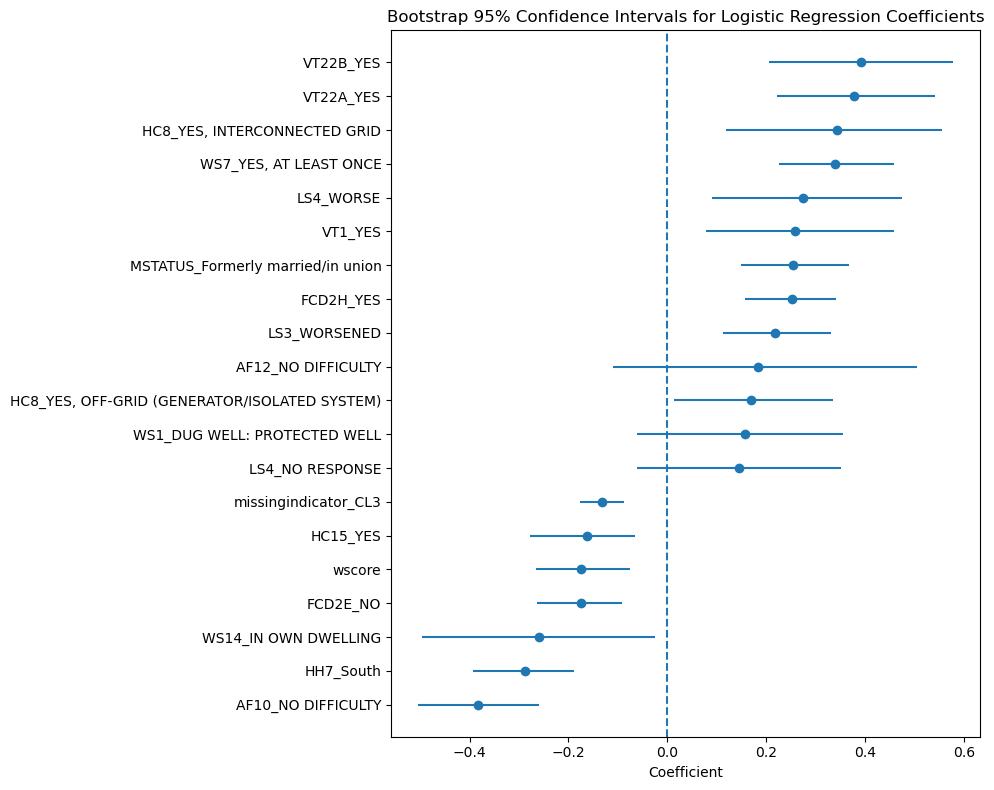

In [55]:
# Plot the top coefficients with 95% bootstrap confidence intervals
top_n = 20
plot_df = coef_ci_df.head(top_n).sort_values("coef")

plt.figure(figsize=(10, 8))

# Compute error bars for the confidence intervals
y_pos = np.arange(len(plot_df))
x = plot_df["coef"].values
xerr = np.vstack([
    np.maximum(0, x - plot_df["ci_low"].values),
    np.maximum(0, plot_df["ci_high"].values - x)
])

#Plot coefficients with error bars
plt.errorbar(x, y_pos, xerr=xerr, fmt="o")
plt.axvline(0, linestyle="--")
plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Coefficient")
plt.title("Bootstrap 95% Confidence Intervals for Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

The figure above shows the 95% bootstrap confidence intervals for the top 21 coefficients, ranked by the absolute value of their point estimates. This allows us to focus on the variables with the strongest estimated effects in the model.
A key takeaway from the plot is that most of the confidence intervals do not cross zero. This suggests that the selected variables have a relatively stable and consistent contribution to the model across different bootstrap samples. In other words, the feature selection procedure based on L1 regularisation, followed by the L2 model, appears to have identified variables that genuinely carry predictive signal for distinguishing between depressed and non depressed individuals.

In particular, the meanings of the variables shown above are the following:

**Positive association with depression**

**VT22B_YES**: experience of sex discrimination (mother / woman);
**VT22A_YES**: experience of ethnic or immigration discrimination (mother / woman);
**WS7_YES, AT LEAST ONCE**: household ran out of drinking water at least once (household);
**HC8_YES, INTERCONNECTED GRID**: access to electricity from the main grid (household);
**MSTATUS_Formerly married/in union**: formerly married or in union (mother / woman);
**LS4_WORSE**: expectation that life will be worse in the future(mother / woman);
**LSA_NO_RESPONSE**: no response on the expectation that life will be worse in the future (mothe/woman);
**VT1_YES**: exposure to a victimisation-related event (mother / woman);
**AF12_NO DIFFICULTY**: no difficulty communicating (mother / woman);
**LS3_WORSENED**: perceived worsening of life compared to the past (mother / woman);
**FCD2H_YES**: child exposed to verbal aggression (e.g. being insulted) (child);
**HC8_YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)**: off-grid electricity access (household);
**WS1_DUG WELL**: PROTECTED WELL: protected dug well as water source (household);
**WS11_PIT LATRINE**: PIT LATRINE WITHOUT SLAB / OPEN PIT: unimproved sanitation facility (household);

**Negative association with depression**

**missingindicator_CL3**: no child work hours recorder (child)
**HC15_YES**: the household owns land for agriculture (household);
**FCD2E_NO**: absence of certain disciplinary practices (child / household);
**wscore**: household wealth index (household);
**WS14_IN OWN DWELLING**: sanitation facility located within the dwelling (household);
**AF10_NO DIFFICULTY**: no difficulty remembering or concentrating (mother / woman);
**HH7_South**: residence in the Southern region (household / geographic context);


## Random Forest Classifier

We fit a more complex model to understand if, exploiting unlinear pattern in data, we can reach higher prediction accuracy.

c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


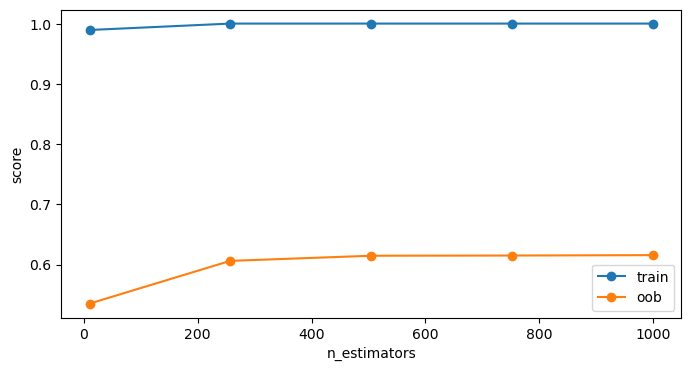

In [56]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define a range of n_estimators to test
n_est = np.linspace(10, 1000, 5, dtype=int)

#Initialize lists to store training and OOB scores
train_scores = []
oob_scores = []

#Fit a random forest model for each value of n_estimators and store the training and OOB scores
for n in n_est:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train_transformed_df, y_train)
    train_scores.append(rf.score(X_train_transformed_df, y_train))
    oob_scores.append(rf.oob_score_)

#Plot the training and OOB scores as a function of n_estimators
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_xlabel("n_estimators")
ax.set_ylabel("score")
ax.plot(n_est, train_scores, marker="o", label="train")
ax.plot(n_est, oob_scores, marker="o", label="oob")
ax.legend()
plt.show()

Before fitting the final Random Forest model, we first explore a reasonable value for the number of trees, n_estimators, which is one of the main tuning parameters of the method. In a Random Forest, n_estimators indicates how many decision trees are built and then aggregated to produce the final prediction. In general, increasing the number of trees tends to improve stability and reduce variance, but beyond a certain point the gain becomes very small while the computational cost keeps increasing.

To guide this choice, we fit a sequence of Random Forest models with different values of n_estimators and compare both the training score and the out-of-bag (OOB) score. The OOB score is obtained by using, for each tree, the observations that were not included in its bootstrap sample as a small validation set. This provides an internal estimate of predictive performance without the need for a separate validation split.

From the plot, the training score is very high for all values of n_estimators, while the OOB score improves noticeably at first and then stabilises. In particular, after around 300 trees, the increase in the OOB score becomes only marginal. For this reason, we take n_estimators = 300 as a reasonable choice in the subsequent fitting.

In [ ]:
# Pipeline: preprocessing + random forest
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        random_state=0,
        n_jobs=-1
    )
)

# Small but reasonable grid
param_grid = {
    "randomforestclassifier__n_estimators": [300],
    "randomforestclassifier__max_depth": [None, 10],
    "randomforestclassifier__min_samples_split": [2, 5],
    "randomforestclassifier__min_samples_leaf": [1, 2],
    "randomforestclassifier__max_features": ["sqrt", 0.5]
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grid search
rf_gs = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=["accuracy", "f1", "recall", "precision", "roc_auc"],
    cv=cv,
    refit="roc_auc",
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
rf_gs.fit(X_train, y_train)

# Best tuned pipeline
best_rf_pipe = rf_gs.best_estimator_

# Test set evaluation
acc_rf = best_rf_pipe.score(X_test, y_test)
print("Random forest test set accuracy:", round(acc_rf, 4))

#Compute AUC on the test set
y_proba_rf = best_rf_pipe.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"Random forest AUC: {auc_rf:.4f}")

print("Best RF parameters:")
print(rf_gs.best_params_)

#Print classification report
print(classification_report(y_test, best_rf_pipe.predict(X_test), 
                            target_names=["No Depression", "Depression"]))

# Feature importances
best_preprocessor = best_rf_pipe[0]
best_rf_model = best_rf_pipe[-1]

# Get the names of the transformed features after preprocessing
feature_names = best_preprocessor.get_feature_names_out()

# Build a DataFrame of feature importances
rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importance_df.head(20))

c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [18, 54] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random forest test set accuracy: 0.6177


c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [18, 54] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random forest AUC: 0.6477
Best RF parameters:
{'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 300}


c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [18, 54] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Surface\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


               precision    recall  f1-score   support

No Depression       0.61      0.44      0.51      1772
   Depression       0.62      0.76      0.69      2139

     accuracy                           0.62      3911
    macro avg       0.62      0.60      0.60      3911
 weighted avg       0.62      0.62      0.61      3911

       feature  importance
191     wscore    0.046878
190        WB4    0.036556
187        MA2    0.034035
189        WS4    0.031544
175        LS2    0.029343
188       CL13    0.027213
192        CB3    0.026699
193      CSURV    0.024234
181  ethnicity    0.024068
171       WB6B    0.023996
173       CB5B    0.023040
178        LS1    0.019466
176       VT20    0.019052
177       VT21    0.017624
170       WB14    0.014653
186        CL3    0.012956
172       WB6A    0.011482
199      CDEAD    0.010691
154  HH7_South    0.009327
169   HL4_Male    0.007782


We then fit a Random Forest classifier on the full preprocessed training set. The idea behind this step is to check whether allowing for more flexible and non linear relationships improves predictive performance. For this reason, unlike the logistic regression, the Random Forest is trained on the full feature space rather than only on the subset selected by the earlier L1-L2 procedure. The model is tuned by cross-validation over a small grid of reasonable values for the main hyperparameters (due to computational constraints), and the final model is selected using AUC as the refitting criterion.

In principle, this type of model is attractive because it can capture interactions and non-linear patterns that a standard logistic regression may miss. However, in our case the results show only a very limited improvement, if any, in the main performance measures. Test accuracy remains around 0.62, while AUC is also only slightly above 0.60. This is very close to what we obtained with the final L2 logistic regression. So, although the Random Forest is more flexible, that extra flexibility does not translate into a meaningful gain in predictive power.

Taken together, these results suggest that the signal present in the data is probably not especially strong. In other words, the modest performance does not seem to be mainly due to model misspecification or to the inability of a linear model to capture non-linear effects. Rather, the available predictors appear to contain only a limited amount of information about the target. For this reason, the L2 logistic regression remains the preferable final model, since it offers essentially similar predictive performance while being much easier to interpret.

The feature importance output from the Random Forest is still useful as a complementary check, but it should be interpreted differently from the coefficients of the logistic regression. In the Random Forest, feature importance measures how much a variable contributes to reducing impurity across the trees, so it is not directly comparable to the sign and magnitude of a regression coefficient. One noticeable pattern is that the Random Forest tends to assign relatively high importance to numeric variables, such as wscore, WB4, MA2, WS4, CL13, CB3, and CSURV, whereas categorical variables appear less prominently in the top part of the ranking.

At the same time, there is some overlap with the variables highlighted by the logistic regression. In particular, variables such as wscore, AF10_NO DIFFICULTY, and HH7_South also appeared among the more important predictors in the L2 model. This is reassuring, because it suggests that at least part of the signal picked up by the two approaches is consistent. Still, the overlap is only partial, and the Random Forest ranking places more weight on continuous or discrete variables than the logistic model did. This difference is not surprising, since the two models measure “importance” in different ways and rely on different decision rules.

# Interpretation, Discussion & Conclusions

The final model selected for this project is an L2 penalised logistic regression fitted on a reduced set of variables compared with the full dataset provided, that have been selected through a bootstrap L1 procedure. This model was chosen because it offers the best trade off between predictive performance and interpretability.

1. **Overall performance of the final model**

The predictive performance of the model is only moderate. On the test set, both accuracy and AUC are around 0.60, so the model is not able to separate depressed from non depressed children very effectively. 

At the same time, one result is still worth noting. Despite the fact that the model does not have strong discriminatory power between depressed and non depressed children, the recall for the depression class is still around 0.70. This means that, according to the test set results, the model is able to identify about 70% of the children who actually show some form of depressive symptom. In this sense, if the main interest is to reduce the number of depressed children who are not correctly identified, the model still performs reasonably well.

For this reason, although the model should not be interpreted as a diagnostic tool, it may still be useful as a first screening instrument, especially in settings where the priority is to flag potentially vulnerable children for further assessment.


2. **Variables associated with higher odds of depression**

One important advantage of logistic regression is that it allows us to inspect the coefficients directly. This makes the model easier to interpret than more complex alternatives.
The coefficients are linked to the odds of the positive class, that is, the ratio between the probability of depression and the probability of no depression, given the set of features. Without entering too much in detail, a positive coefficient is therefore associated with higher odds of depression, while a negative coefficient is associated with lower odds.

For this reason, the selected model can provide useful information about which variables seem to matter most in the in explaining child's depression within our dataset.

An interesting insight that we get from the coefficient inspection is that several of the variables most strongly associated with the depression class are related to the mother’s condition rather than to the child alone. In total, among the fourteen most important variables associated with depression within our model, 57% are related to the mother conditions (8 over 14).

For example:

VT22A_YES, referring to the mother’s reported experience of ethnic or immigration discrimination, is associated with an increase in the odds of depression by a factor between about 1.24 and 1.71.
LS3_WORSENED, indicating that the mother reports her life as having worsened compared with the previous year, is associated with an increase in the odds of depression by a factor between about 1.11 and 1.39.

These are not small effects, and they suggest that the child’s emotional condition may be strongly related to the social and emotional vulnerability of the mother.

Other relevant variables are instead linked to the general socio-economic condition of the household (36% of the fourteen most important coefficients for explaining depression). For instance:

WS7_YES, AT LEAST ONCE, indicating that the household ran out of drinking water at least once, is associated with an increase in the odds of depression by a factor between about 1.25 and 1.58.

This is a more intuitive result, because water insecurity is a plausible indicator of general material hardship.

3. **Variables associated with lower odds of depression**

The variables associated with lower odds of depression also provide some useful information. Most of them are related to household general conditions (66%, 4 over the 6 most important)

For example:

the missingness indicator for CL3 (hours of child labour) is associated with lower odds of depression, with an odds ratio between about 0.83 and 0.92;
FCD2E_NO, indicating the absence of a specific negative disciplinary practice, is associated with lower odds by a factor between about 0.76 and 0.91;
some indicators of household living conditions are also associated with the no depression class.

These negative associations again point towards a fairly coherent picture: the variables associated with lower odds of depression are often linked to better household conditions, or to the absence of adverse experiences (missingness of hours of child labour is informative in this sense).


4. **Main implications**

Even though the model is not highly accurate, it still suggests some useful directions for policy and practice.

First, the results support the idea that child mental health should not be approached only at the individual child level. There is evidence that the mother’s social and emotional vulnerability is closely linked to the child outcome. This suggests that interventions aimed at improving the mental and social well being of mothers may also have indirect benefits for children, at least at an associational level.

Second, the results also point to the relevance of household hardship. Water insecurity, poor sanitation, and broader material disadvantage appear repeatedly among the important predictors. This suggests that social and economic policies play also an important role for child mental health. 

Third, the model highlights and reinforce the importance of monitoring violence, discrimination, and family stress in future surveys.

5. **Main limitations**

The most important limitation of this analysis is the target variable itself. The outcome used here is based on a single survey item asking how often the child seems “very sad or depressed”, and this was then turned into a binary variable. This is clearly a rough approximation of depression, not a clinical diagnosis.

This matters because standard clinical classifications such as ICD-10 and ICD-11 to make an example (INTERNATIONAL CLASSIFICATION OF DISEASES - Mortality and Morbidity Statistics, developed by WHO) define depressive disorders much more broadly, including not only sad mood but also other symptoms such as reduced interest, fatigue, poor concentration, sleep or appetite changes, guilt, hopelessness, and impairment in functioning. A better and more clinically grounded target variable would probably make the signal in the data much stronger.

A second limitation is the quality of the data more generally. Several predictors have a high proportion of missing values, sometimes above 20%. Although the imputation strategies used in the analysis are reasonable, missingness of this size can still introduce noise and uncertainty.

A third limitation is that the analysis is not causal. The model identifies variables that are associated with the outcome and help classification, but it does not tell us whether these variables truly cause depression.

6. **Future work**

Future work on this dataset could develop in at least three directions.

First, it may be useful to consider spatial or multilevel models, since some geographic variables seem to matter and the data may contain meaningful clustering across areas (for example, the variable HH7_South, indicating that south region is related with lower odds of depression).
Second, the analysis could benefit from more expert driven feature construction, for example through selected interaction terms or targeted transformations suggested by substantive knowledge on childhood and adolescent depression.
Third, a Bayesian approach could be useful, since it would allow a fuller description of parameter uncertainty and provide more flexible inference on the coefficients.

Most importantly, however, future data collection would benefit from a more specific measure of childhood depression, based on a broader set of symptoms and more closely aligned with established diagnostic frameworks.

# Generative AI statement

GenAI was used to help with checking grammar and debugging purposes.

# References

- World Health Organization (2016), International Statistical Classification of Diseases and Related Health Problems, 10th Revision, Fifth Edition, Geneva: WHO.
- World Health Organization (2018), International Classification of Diseases for Mortality and Morbidity Statistics (ICD-11 MMS), Geneva: WHO

In [58]:
# Run the following to render to PDF
#!jupyter nbconvert --to pdf project.ipynb